# MetaLore: Smart City Wireless Network Simulator

A Gymnasium-compatible reinforcement learning environment for simulating wireless networks with base stations, user equipment (UEs), and IoT sensors.

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv, MultiCellEnv
from metalore.config import default_config, small_config, large_config, mobile_sensor_config, dynamic_traffic_config, multi_cell_config

print("MetaLore imported successfully!")

MetaLore imported successfully!


## 2. Environment Configurations

MetaLore provides several pre-configured environments:
- **small**: Minimal setup for quick testing
- **default**: Standard single-cell configuration
- **large**: Larger scale with more entities
- **multi_cell**: Multiple base stations for complex scenarios

In [2]:
# Compare environment configurations
configs = {
    'small': (SingleCellEnv, small_config()),
    'default': (SingleCellEnv, default_config()),
    'large': (SingleCellEnv, large_config()),
    'mobile_sensor': (SingleCellEnv, mobile_sensor_config()),
    'dynamic_traffic': (SingleCellEnv, dynamic_traffic_config()),
    'multi_cell': (MultiCellEnv, multi_cell_config()),
}

rows = []
for name, (EnvClass, config) in configs.items():
    env = EnvClass(config=config)
    env.reset()
    rows.append({
        'Config': name,
        'BSs': env.num_bs,
        'UEs': env.num_ues,
        'Sensors': env.num_sensors,
        'Width': env.width,
        'Height': env.height,
        'Max Steps': env.EP_MAX_TIME,
    })
    env.close()

config_df = pd.DataFrame(rows)
ipd.display(config_df)

,Config,BSs,UEs,Sensors,Width,Height,Max Steps
0,small,1,5,8,200.0,200.0,100
1,default,1,3,3,200.0,200.0,100
2,large,1,20,10,200.0,200.0,100
3,mobile_sensor,1,10,5,200.0,200.0,100
4,dynamic_traffic,1,50,5,200.0,200.0,100
5,multi_cell,3,15,20,200.0,200.0,100


## 3. Running the Simulation

The environment follows the standard Gymnasium API:
- `reset()` - Initialize/reset the environment
- `step(action)` - Take an action and advance simulation
- `render()` - Visualize current state

In [3]:
# Create environment
env = SingleCellEnv(config=default_config())
obs, info = env.reset()

print("="*60)
print("ENVIRONMENT SETUP")
print("="*60)
print(f"Base Stations: {env.num_bs}")
print(f"User Equipment: {env.num_ues}")
print(f"Sensors: {env.num_sensors}")
print(f"Area: {env.width} x {env.height}")
print(f"Max Steps: {env.EP_MAX_TIME}")
print()
print("="*60)
print("RL INTERFACE")
print("="*60)
print(f"Action Space: {env.action_space}")
print(f"Observation Space: {env.observation_space}")
print(f"Initial Observation Shape: {obs.shape}")

ENVIRONMENT SETUP
Base Stations: 1
User Equipment: 3
Sensors: 3
Area: 200.0 x 200.0
Max Steps: 100

RL INTERFACE
Action Space: Box(0.0, 1.0, (2,), float32)
Observation Space: Box(0.0, 10000.0, (2,), float32)
Initial Observation Shape: (2,)


Completed 100 steps
Total Reward: 1682.22
Mean Reward: 16.8222


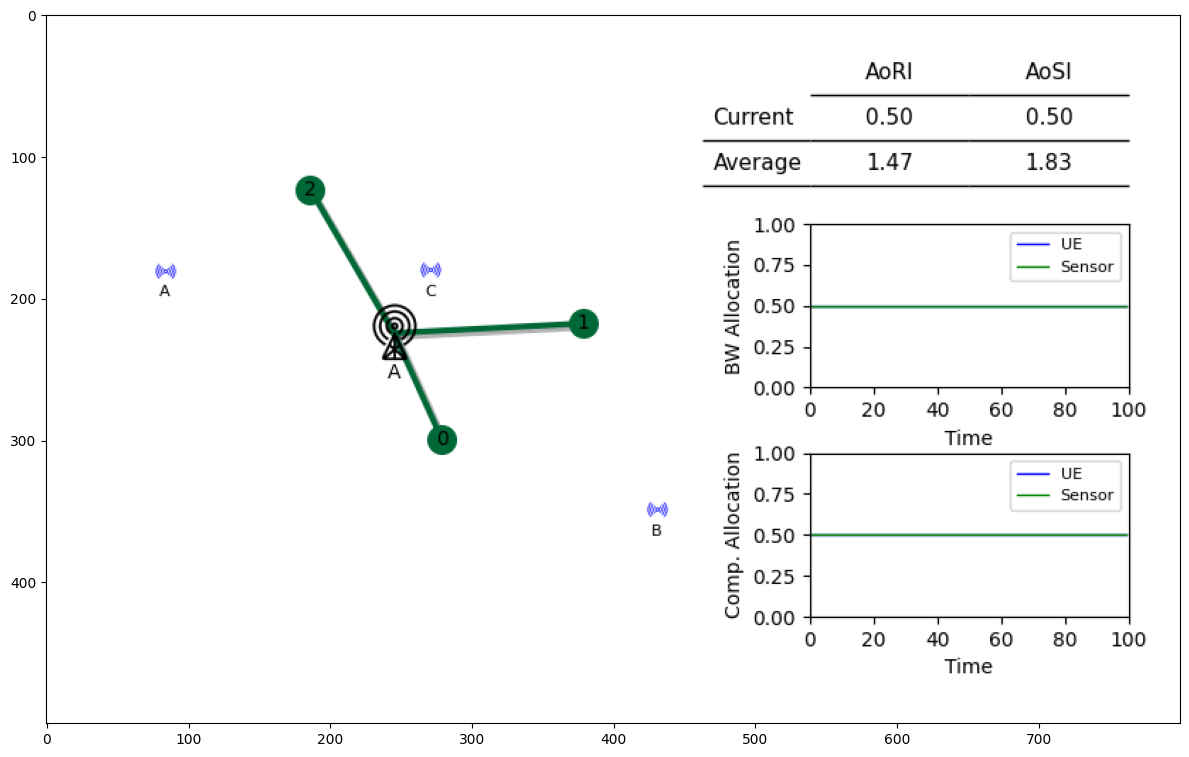

In [4]:
# Run simulation for N steps
N_STEPS = 100

rewards = []
observations = []

for step in range(N_STEPS):
    #action = env.action_space.sample()
    action = [0.5, 0.5]
    obs, reward, terminated, truncated, info = env.step(action)
    
    rewards.append(reward)
    observations.append(obs)
    
    if terminated or truncated:
        print(f"Episode ended at step {step+1}")
        break

    # Animate during simulation
    ipd.clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(env.render())
    plt.tight_layout()
    plt.show()
    plt.close()

# Show final frame (persists after loop)
ipd.clear_output(wait=True)
print(f"Completed {len(rewards)} steps")
print(f"Total Reward: {sum(rewards):.2f}")
print(f"Mean Reward: {np.mean(rewards):.4f}")

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(env.render())
plt.tight_layout()
plt.show()


## 4. Metrics Analysis

The `MetricsTracker` records detailed simulation data at each timestep.

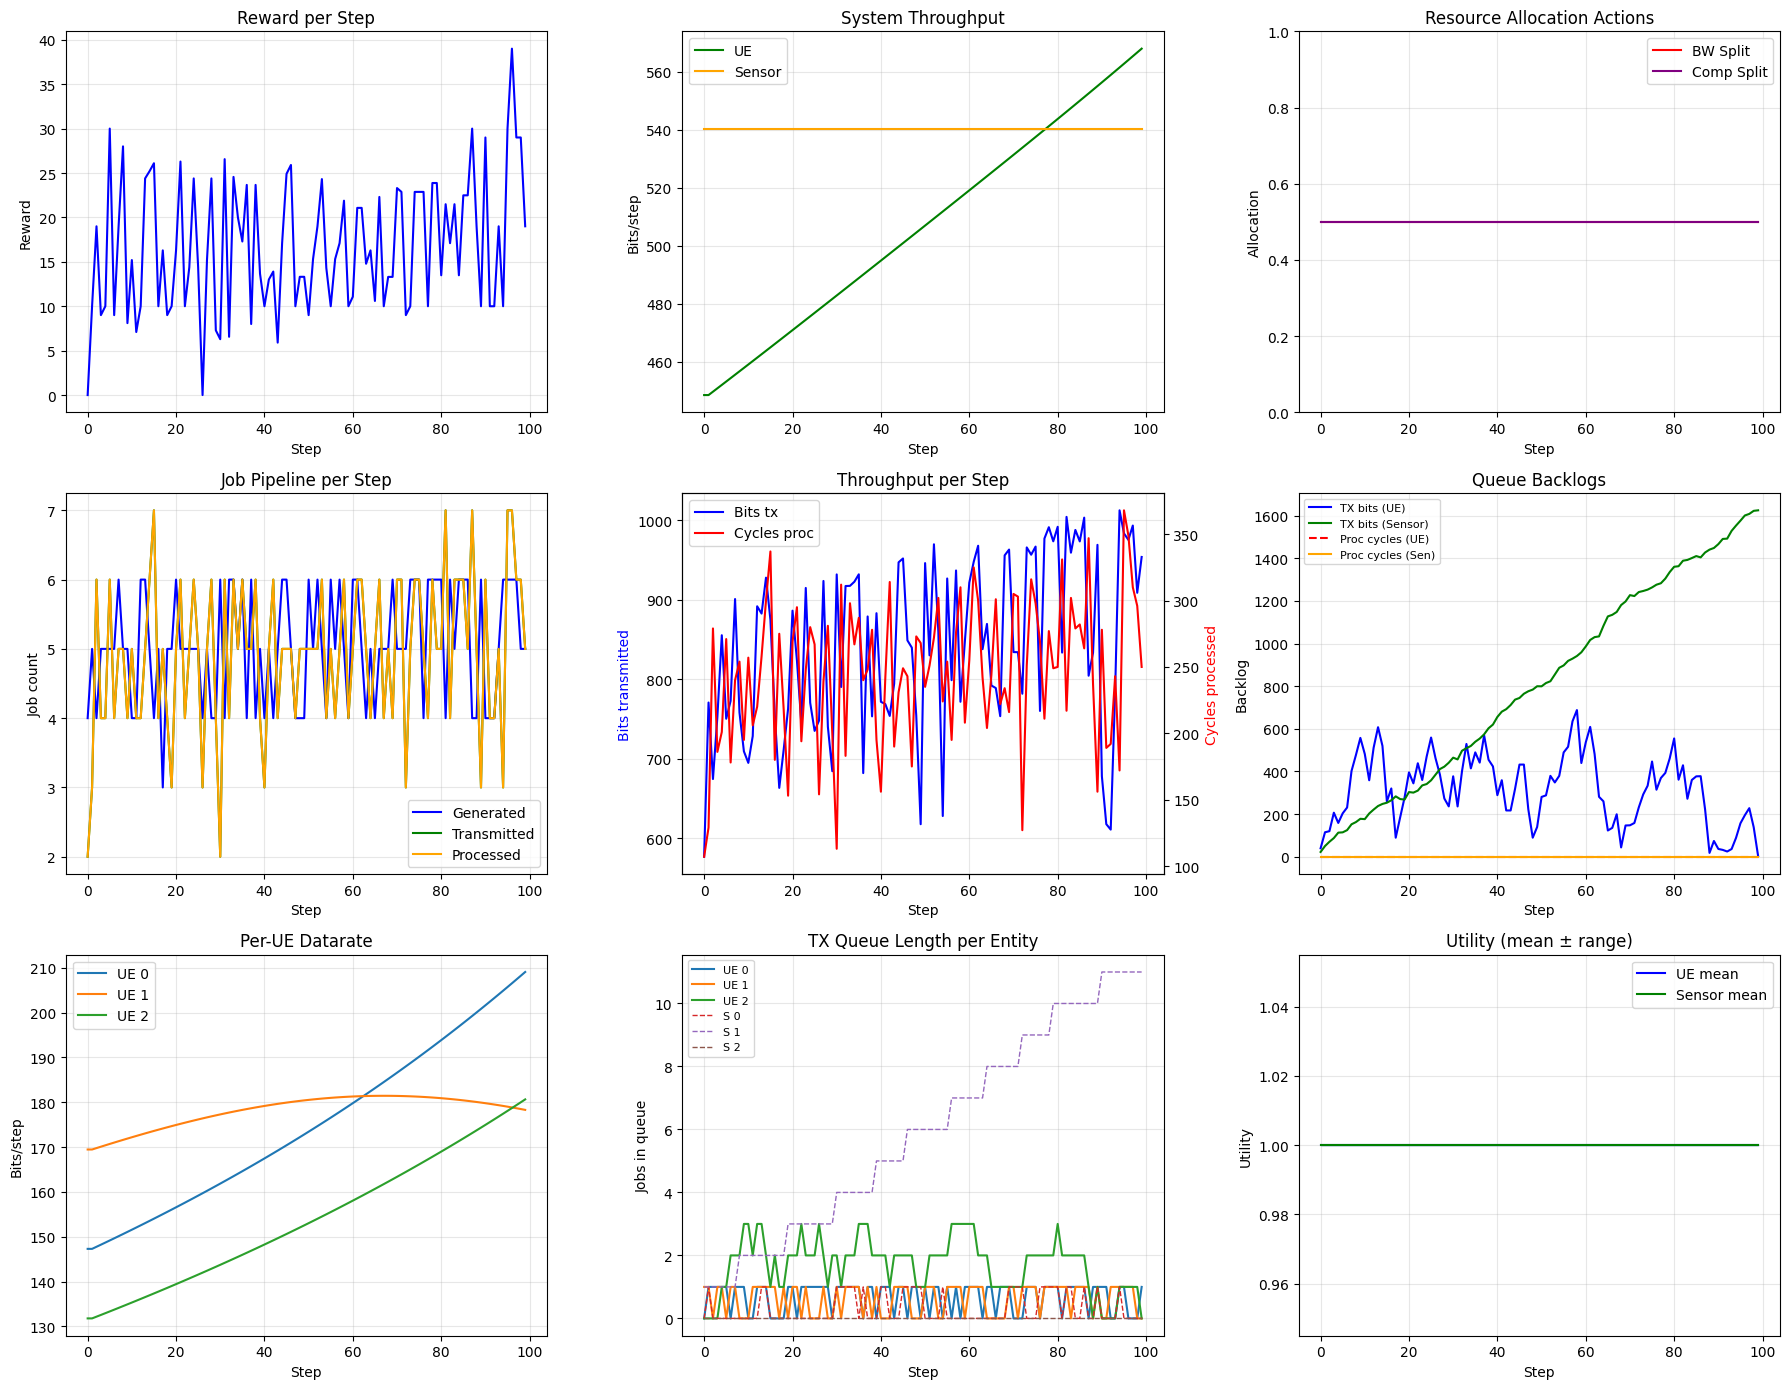

In [5]:
metrics = env.metrics

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# --- Row 1: High-level ---

# Reward
ax = axes[0, 0]
ax.plot(metrics.actions['reward'], 'b-', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Reward')
ax.set_title('Reward per Step'); ax.grid(True, alpha=0.3)

# Throughput
ax = axes[0, 1]
ax.plot(metrics.environment['throughput_ue'], 'g-', label='UE', linewidth=1.5)
ax.plot(metrics.environment['throughput_sensor'], 'orange', label='Sensor', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Bits/step')
ax.set_title('System Throughput'); ax.legend(); ax.grid(True, alpha=0.3)

# Resource allocation
ax = axes[0, 2]
ax.plot(metrics.actions['bw_split'], 'r-', label='BW Split', linewidth=1.5)
ax.plot(metrics.actions['comp_split'], 'purple', label='Comp Split', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Allocation')
ax.set_title('Resource Allocation Actions')
ax.legend(); ax.set_ylim([0, 1]); ax.grid(True, alpha=0.3)

# --- Row 2: Job pipeline ---

# Jobs per step
ax = axes[1, 0]
ax.plot(metrics.jobs['jobs_generated'],   'b-',     label='Generated',   linewidth=1.5)
ax.plot(metrics.jobs['jobs_transmitted'], 'g-',     label='Transmitted', linewidth=1.5)
ax.plot(metrics.jobs['jobs_processed'],   'orange', label='Processed',   linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Job count')
ax.set_title('Job Pipeline per Step'); ax.legend(); ax.grid(True, alpha=0.3)

# Bits & cycles throughput
ax = axes[1, 1]
ax2 = ax.twinx()
ax.plot(metrics.jobs['bits_transmitted'],  'b-', linewidth=1.5, label='Bits tx')
ax2.plot(metrics.jobs['cycles_processed'], 'r-', linewidth=1.5, label='Cycles proc')
ax.set_xlabel('Step'); ax.set_ylabel('Bits transmitted', color='b')
ax2.set_ylabel('Cycles processed', color='r')
ax.set_title('Throughput per Step')
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines]); ax.grid(True, alpha=0.3)

# Queue backlogs
ax = axes[1, 2]
ax.plot(metrics.jobs['tx_queue_bits_ue'],         'b-',     label='TX bits (UE)',      linewidth=1.5)
ax.plot(metrics.jobs['tx_queue_bits_sensor'],     'g-',     label='TX bits (Sensor)',  linewidth=1.5)
ax.plot(metrics.jobs['proc_queue_cycles_ue'],     'r--',    label='Proc cycles (UE)',  linewidth=1.5)
ax.plot(metrics.jobs['proc_queue_cycles_sensor'], 'orange', label='Proc cycles (Sen)', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Backlog')
ax.set_title('Queue Backlogs'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# --- Row 3: Per-entity ---

# Per-UE datarates
ax = axes[2, 0]
for ue_id, rates in metrics.performance['datarates_ue'].items():
    ax.plot(rates, label=f'UE {ue_id}', linewidth=1.5)
ax.set_xlabel('Step'); ax.set_ylabel('Bits/step')
ax.set_title('Per-UE Datarate'); ax.legend(); ax.grid(True, alpha=0.3)

# Per-UE TX queue length
ax = axes[2, 1]
for ue_id, lengths in metrics.performance['tx_queue_length_ue'].items():
    ax.plot(lengths, label=f'UE {ue_id}', linewidth=1.5)
for sensor_id, lengths in metrics.performance['tx_queue_length_sensor'].items():
    ax.plot(lengths, '--', label=f'S {sensor_id}', linewidth=1)
ax.set_xlabel('Step'); ax.set_ylabel('Jobs in queue')
ax.set_title('TX Queue Length per Entity'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Mean utility
ax = axes[2, 2]
util_ue_df = pd.DataFrame(dict(metrics.performance['utilities_ue']))
util_sensor_df = pd.DataFrame(dict(metrics.performance['utilities_sensor']))
if not util_ue_df.empty:
    ax.plot(util_ue_df.mean(axis=1), 'b-', label='UE mean', linewidth=1.5)
    ax.fill_between(range(len(util_ue_df)), util_ue_df.min(axis=1), util_ue_df.max(axis=1), alpha=0.2, color='b')
if not util_sensor_df.empty:
    ax.plot(util_sensor_df.mean(axis=1), 'g-', label='Sensor mean', linewidth=1.5)
    ax.fill_between(range(len(util_sensor_df)), util_sensor_df.min(axis=1), util_sensor_df.max(axis=1), alpha=0.2, color='g')
ax.set_xlabel('Step'); ax.set_ylabel('Utility')
ax.set_title('Utility (mean ± range)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Detailed Metrics Tables

Raw data for each timestep.

In [6]:
# Environment & Throughput
print("ENVIRONMENT & THROUGHPUT")
env_df = pd.DataFrame({
    'Time':              metrics.environment['time'],
    'Active UEs':        metrics.environment['num_active_ues'],
    'Active Sensors':    metrics.environment['num_active_sensors'],
    'Throughput UE':     [f"{x:.1f}" for x in metrics.environment['throughput_ue']],
    'Throughput Sensor': [f"{x:.1f}" for x in metrics.environment['throughput_sensor']],
})
ipd.display(env_df)

# Actions & Reward
print("\nACTIONS & REWARD")
actions_df = pd.DataFrame({
    'BW Split':   [f"{x:.3f}" for x in metrics.actions['bw_split']],
    'Comp Split': [f"{x:.3f}" for x in metrics.actions['comp_split']],
    'Reward':     [f"{x:.4f}" for x in metrics.actions['reward']],
})
ipd.display(actions_df)

# Job pipeline per step
print("\nJOB PIPELINE PER STEP")
jobs_df = pd.DataFrame({
    'Jobs Generated':    metrics.jobs['jobs_generated'],
    'Jobs Transmitted':  metrics.jobs['jobs_transmitted'],
    'Jobs Processed':    metrics.jobs['jobs_processed'],
    'Bits Transmitted':  [f"{x:.1f}" for x in metrics.jobs['bits_transmitted']],
    'Cycles Processed':  [f"{x:.1f}" for x in metrics.jobs['cycles_processed']],
    'TX Queue (UE)':     metrics.jobs['tx_queue_jobs_ue'],
    'TX Queue (Sensor)': metrics.jobs['tx_queue_jobs_sensor'],
    'Proc Queue (UE)':   metrics.jobs['proc_queue_jobs_ue'],
    'Proc Queue (Sen)':  metrics.jobs['proc_queue_jobs_sensor'],
})
ipd.display(jobs_df)


ENVIRONMENT & THROUGHPUT


,Time,Active UEs,Active Sensors,Throughput UE,Throughput Sensor
0,0,3,3,448.6,540.2
1,1,3,3,448.6,540.2
2,2,3,3,449.7,540.2
3,3,3,3,450.9,540.2
4,4,3,3,452.1,540.2
...,...,...,...,...,...
95,95,3,3,562.8,540.2
96,96,3,3,564.1,540.2
97,97,3,3,565.4,540.2
98,98,3,3,566.7,540.2



ACTIONS & REWARD


,BW Split,Comp Split,Reward
0,0.500,0.500,0.0000
1,0.500,0.500,10.0000
2,0.500,0.500,19.0000
3,0.500,0.500,9.0000
4,0.500,0.500,10.0000
...,...,...,...
95,0.500,0.500,30.0000
96,0.500,0.500,39.0000
97,0.500,0.500,29.0000
98,0.500,0.500,29.0000



JOB PIPELINE PER STEP


,Jobs Generated,Jobs Transmitted,Jobs Processed,Bits Transmitted,Cycles Processed,TX Queue (UE),TX Queue (Sensor),Proc Queue (UE),Proc Queue (Sen)
0,4,2,2,577.1,107.0,1,1,0,0
1,5,3,3,771.0,129.0,2,2,0,0
2,4,6,6,674.8,279.0,1,1,0,0
3,5,4,4,752.9,186.0,2,1,0,0
4,5,4,4,855.7,201.0,3,1,0,0
...,...,...,...,...,...,...,...,...,...
95,6,7,7,983.7,368.0,3,11,0,0
96,6,7,7,975.6,349.0,2,11,0,0
97,6,6,6,993.6,310.0,2,11,0,0
98,5,6,6,909.0,296.0,1,11,0,0


In [7]:
# Per-entity datarates
print("UE DATARATES (per entity, per timestep)")
datarate_ue = pd.DataFrame(dict(metrics.performance['datarates_ue']))
datarate_ue.columns = [f'UE {c}' for c in datarate_ue.columns]
ipd.display(datarate_ue.round(2))

print("\nSENSOR DATARATES")
datarate_sensor = pd.DataFrame(dict(metrics.performance['datarates_sensor']))
datarate_sensor.columns = [f'Sensor {c}' for c in datarate_sensor.columns]
ipd.display(datarate_sensor.round(2))

# Per-entity utilities
print("\nUE UTILITIES")
util_ue = pd.DataFrame(dict(metrics.performance['utilities_ue']))
util_ue.columns = [f'UE {c}' for c in util_ue.columns]
ipd.display(util_ue.round(3))

print("\nSENSOR UTILITIES")
util_sensor = pd.DataFrame(dict(metrics.performance['utilities_sensor']))
util_sensor.columns = [f'Sensor {c}' for c in util_sensor.columns]
ipd.display(util_sensor.round(3))

# Per-entity TX queue lengths
print("\nUE TX QUEUE LENGTHS (jobs pending)")
txq_ue = pd.DataFrame(dict(metrics.performance['tx_queue_length_ue']))
txq_ue.columns = [f'UE {c}' for c in txq_ue.columns]
ipd.display(txq_ue)

print("\nSENSOR TX QUEUE LENGTHS (jobs pending)")
txq_sensor = pd.DataFrame(dict(metrics.performance['tx_queue_length_sensor']))
txq_sensor.columns = [f'Sensor {c}' for c in txq_sensor.columns]
ipd.display(txq_sensor)

# Per-UE jobs generated and bits transmitted
print("\nJOBS GENERATED PER UE PER STEP")
jobs_gen_ue = pd.DataFrame(dict(metrics.performance['jobs_generated_ue']))
jobs_gen_ue.columns = [f'UE {c}' for c in jobs_gen_ue.columns]
ipd.display(jobs_gen_ue)

print("\nBITS TRANSMITTED PER UE PER STEP")
bits_tx_ue = pd.DataFrame(dict(metrics.performance['bits_transmitted_ue']))
bits_tx_ue.columns = [f'UE {c}' for c in bits_tx_ue.columns]
ipd.display(bits_tx_ue.round(1))


UE DATARATES (per entity, per timestep)


,UE 0,UE 1,UE 2
0,147.30,169.46,131.79
1,147.30,169.46,131.79
2,147.77,169.78,132.18
3,148.23,170.09,132.57
4,148.70,170.40,132.96
...,...,...,...
95,205.70,179.02,178.08
96,206.53,178.85,178.71
97,207.37,178.67,179.35
98,208.21,178.49,179.99



SENSOR DATARATES


,Sensor 0,Sensor 1,Sensor 2
0,158.65,132.6,248.92
1,158.65,132.6,248.92
2,158.65,132.6,248.92
3,158.65,132.6,248.92
4,158.65,132.6,248.92
...,...,...,...
95,158.65,132.6,248.92
96,158.65,132.6,248.92
97,158.65,132.6,248.92
98,158.65,132.6,248.92



UE UTILITIES


...

,Sensor 0,Sensor 1,Sensor 2
0,0,1,0
1,1,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
95,0,11,0
96,0,11,0
97,0,11,0
98,0,11,0



JOBS GENERATED PER UE PER STEP


,UE 0,UE 1,UE 2
0,0,1,0
1,1,1,0
2,1,0,0
3,1,1,0
4,0,1,1
...,...,...,...
95,1,1,1
96,1,1,1
97,1,1,1
98,1,0,1



BITS TRANSMITTED PER UE PER STEP


,UE 0,UE 1,UE 2
0,0.0,0.0,0.0
1,0.0,209.0,0.0
2,197.0,195.0,0.0
3,218.0,0.0,0.0
4,0.0,224.0,0.0
...,...,...,...
95,220.0,185.0,209.0
96,389.0,217.0,215.0
97,207.0,193.0,211.0
98,202.0,181.0,210.0


## 6. Episode Summary

In [8]:
summary = metrics.summary(env.job_tracker)

print("="*60)
print("EPISODE SUMMARY")
print("="*60)
print(f"Total Steps:        {metrics.num_steps}")
print(f"Total Reward:       {summary['total_reward']:.4f}")
print(f"Mean Reward:        {summary['mean_reward']:.4f}")
print()
print(f"Mean UE Throughput:     {summary['mean_throughput_ue']:.2f} bits/step")
print(f"Mean Sensor Throughput: {summary['mean_throughput_sensor']:.2f} bits/step")
print()
print(f"Mean BW Split:   {np.mean(metrics.actions['bw_split']):.3f}")
print(f"Mean Comp Split: {np.mean(metrics.actions['comp_split']):.3f}")

print()
print("="*60)
print("JOB TOTALS")
print("="*60)
print(f"Generated:   {summary['total_generated']}")
print(f"Transmitted: {summary['total_transmitted']}")
print(f"Processed:   {summary['total_processed']}")
print(f"Completion Rate: {summary['completion_rate']*100:.1f}%")
print(f"Total Bits Transmitted: {summary['total_bits_transmitted']:.1f}")
print(f"Total Cycles Processed: {summary['total_cycles_processed']:.1f}")

print()
print("="*60)
print("PER-ENTITY JOB TOTALS")
print("="*60)
entity_df = pd.DataFrame({
    'Generated':         summary['entity_generated'],
    'Transmitted':       summary['entity_transmitted'],
    'Processed':         summary['entity_processed'],
    'Bits Transmitted':  summary['entity_bits_transmitted'],
    'Cycles Processed':  summary['entity_cycles_processed'],
}).T
entity_df.index.name = 'Metric'
ipd.display(entity_df)

env.close()
print("\nEnvironment closed.")


EPISODE SUMMARY
Total Steps:        100
Total Reward:       1682.2211
Mean Reward:        16.8222

Mean UE Throughput:     506.77 bits/step
Mean Sensor Throughput: 540.17 bits/step

Mean BW Split:   0.500
Mean Comp Split: 0.500

JOB TOTALS
Generated:   505
Transmitted: 493
Processed:   493
Completion Rate: 97.6%
Total Bits Transmitted: 84302.8
Total Cycles Processed: 24621.0

PER-ENTITY JOB TOTALS


UE   SENSOR                         UE         
                        1        0        1        2        0        2
Metric                                                                
Generated            65.0    100.0    100.0    100.0     70.0     70.0
Transmitted          65.0    100.0     89.0    100.0     69.0     70.0
Processed            65.0    100.0     89.0    100.0     69.0     70.0
Bits Transmitted  12926.0  14914.0  13242.0  15033.0  13850.0  14111.0
Cycles Processed   3251.0   4825.0   4599.0   5000.0   3442.0   3504.0


Environment closed.


In [9]:
# Job lifecycle log — only fully processed jobs (all timestamps guaranteed)
job_df = env.job_tracker.to_dataframe()

print(f"Completed jobs: {len(job_df)}")
print()

if not job_df.empty:
    print("LATENCY SUMMARY (timesteps)")
    print(f"  Mean tx queue wait:   {job_df['tx_queue_wait'].mean():.2f}")
    print(f"  Mean tx duration:     {job_df['tx_duration'].mean():.2f}")
    print(f"  Mean proc queue wait: {job_df['proc_queue_wait'].mean():.2f}")
    print(f"  Mean proc duration:   {job_df['proc_duration'].mean():.2f}")
    print(f"  Mean total latency:   {job_df['aoi'].mean():.2f}")
    print(f"  Max total latency:    {job_df['aoi'].max():.0f}")
    print()

    print("PER ENTITY TYPE")
    ipd.display(job_df.groupby('entity_type')[['tx_queue_wait', 'tx_duration', 'proc_queue_wait', 'proc_duration', 'aoi']].mean().round(2))
    print()

    print("JOB LIFECYCLE LOG")
    ipd.display(job_df)

    env.job_tracker.save_log("logs/jobs.csv")
    print("\nSaved: logs/jobs.csv")


Completed jobs: 493

LATENCY SUMMARY (timesteps)
  Mean tx queue wait:   1.04
  Mean tx duration:     0.71
  Mean proc queue wait: 0.00
  Mean proc duration:   0.00
  Mean total latency:   2.67
  Max total latency:    11

PER ENTITY TYPE


,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,aoi
entity_type,,,,,
SENSOR,1.49,0.45,0.0,0.0,NaN
UE,0.39,1.07,0.0,0.0,2.67



JOB LIFECYCLE LOG


,job_id,entity_id,entity_type,data_size,compute_size,generated_at,tx_start_at,tx_end_at,proc_start_at,proc_end_at,tx_queue_wait,tx_duration,proc_queue_wait,proc_duration,nearest_sensor_id,sensor_snapshot_at,aoi,aori,aosi
0,1,0,SENSOR,138.0,52.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
1,3,2,SENSOR,137.0,55.0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,NaN
2,0,1,UE,209.0,41.0,0,0,1,1,1,0,1,0,0,2.0,0.0,1.0,1,0.0
3,2,1,SENSOR,155.0,45.0,0,0,1,1,1,0,1,0,0,NaN,NaN,NaN,1,NaN
4,8,2,SENSOR,163.0,43.0,1,1,1,1,1,0,0,0,0,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
488,501,1,UE,178.0,47.0,99,99,99,99,99,0,0,0,0,2.0,98.0,1.0,0,1.0
489,496,2,UE,187.0,55.0,98,98,99,99,99,0,1,0,0,2.0,98.0,1.0,1,0.0
490,502,0,SENSOR,150.0,49.0,99,99,99,99,99,0,0,0,0,NaN,NaN,NaN,0,NaN
491,446,1,SENSOR,146.0,53.0,88,98,99,99,99,10,1,0,0,NaN,NaN,NaN,11,NaN



Saved: logs/jobs.csv


## 7. Sensor Synchronisation & Age of Information

Analysis of UE job processing quality through three metrics:
- **AoRI** (Age of Request Information): `proc_end_at − generated_at` — UE job's own e2e latency
- **AoI** (Age of Information): `proc_end_at − sensor_snapshot_at` — staleness of sensor data at processing time
- **AoSI** (Age of Sensor Information): `|sensor_snapshot_at − generated_at|` — sensor data age relative to job birth

AGE METRICS (UE jobs)
  AoRI   mean=1.47  median=1.00  max=4  min=0
  AoI    mean=2.67  median=1.00  max=11  min=1
  AoSI   mean=2.00  median=1.00  max=10  min=0


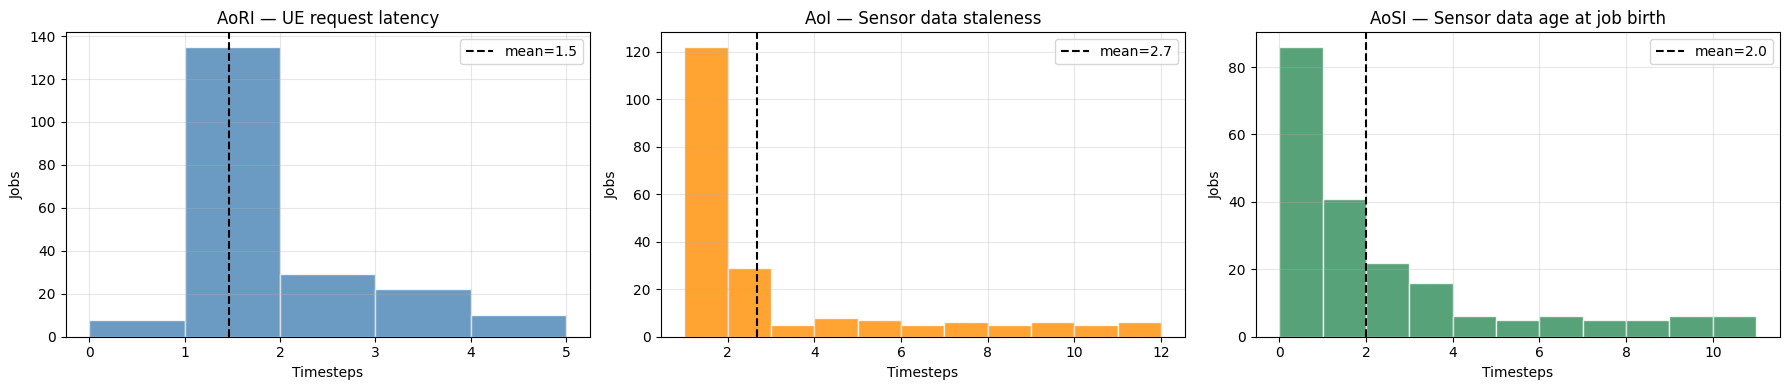


PER-UE AGE METRICS


,aori,aoi,aosi
UE 0,0.97,5.58,4.61
UE 1,0.95,1.00,0.05
UE 2,2.43,1.34,1.23



UE JOB LOG


,job_id,entity_id,generated_at,proc_end_at,nearest_sensor_id,sensor_snapshot_at,aori,aoi,aosi
0,0,1,0,1,2.0,0.0,1,1.0,0.0
1,4,0,1,2,1.0,0.0,1,2.0,1.0
2,5,1,1,2,2.0,1.0,1,1.0,0.0
3,9,0,2,3,1.0,1.0,1,2.0,1.0
4,14,1,3,4,2.0,3.0,1,1.0,0.0
...,...,...,...,...,...,...,...,...,...
199,495,0,98,98,2.0,97.0,0,1.0,1.0
200,490,1,97,98,2.0,97.0,1,1.0,0.0
201,491,2,97,98,2.0,97.0,1,1.0,0.0
202,501,1,99,99,2.0,98.0,0,1.0,1.0


In [10]:
job_df = env.job_tracker.to_dataframe()
ue_df = job_df[job_df['entity_type'] == 'UE'].copy()

# --- AoI / AoRI / AoSI stats ---
print("="*60)
print("AGE METRICS (UE jobs)")
print("="*60)
for col, label in [('aori', 'AoRI'), ('aoi', 'AoI'), ('aosi', 'AoSI')]:
    s = ue_df[col].dropna()
    print(f"  {label:5s}  mean={s.mean():.2f}  median={s.median():.2f}  max={s.max():.0f}  min={s.min():.0f}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (col, label, color) in zip(axes, [
    ('aori', 'AoRI — UE request latency',          'steelblue'),
    ('aoi',  'AoI — Sensor data staleness',        'darkorange'),
    ('aosi', 'AoSI — Sensor data age at job birth', 'seagreen'),
]):
    data = ue_df[col].dropna()
    if data.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.hist(data, bins=range(int(data.min()), int(data.max()) + 2), color=color, alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'mean={data.mean():.1f}')
        ax.legend()
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Jobs')
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Per-UE breakdown ---
print()
print("="*60)
print("PER-UE AGE METRICS")
print("="*60)
per_ue = ue_df.groupby('entity_id')[['aori', 'aoi', 'aosi']].mean().round(2)
per_ue.index = [f'UE {i}' for i in per_ue.index]
ipd.display(per_ue)

# --- Full UE job table with sensor context columns ---
print()
print("UE JOB LOG")
cols = ['job_id', 'entity_id', 'generated_at', 'proc_end_at',
        'nearest_sensor_id', 'sensor_snapshot_at', 'aori', 'aoi', 'aosi']
ipd.display(ue_df[cols].reset_index(drop=True))